# Customer Segmentation

# End-to-End E-Commerce Customer Segmentation

**Objective:** To transform raw transactional data into actionable customer segments using RFM analysis and K-Means clustering, and to lay the groundwork for a personalized product recommendation system.

## Phase 1: Data Ingestion & Quality Control

Before applying any machine learning algorithms, we must establish a clean, reliable data foundation. Real-world e-commerce data is notoriously noisy, containing incomplete records and complex transactional states (like returns and cancellations). 


### Step 1: Loading the Transactional Database
*Technical Insight:* The UK-based UCI dataset contains special characters in product descriptions. Using the `unicode_escape` encoding prevents `UnicodeDecodeError` exceptions during ingestion—a common hurdle in real-world data pipelines.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

In [3]:
df=pd.read_csv('retail_customer_segmentation.csv')
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


**Attribute Information:**

* Invoice: Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction. If this code starts with the letter 'c', it indicates a cancellation.
* StockCode: Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product.
* Description: Product (item) name. Nominal.
* Quantity: The quantities of each product (item) per transaction. Numeric.
* InvoiceDate: Invice date and time. Numeric. The day and time when a transaction was generated.
* Price: Unit price. Numeric. Product price per unit in sterling (Â£).
* CustomerID: Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.
* Country: Country name. Nominal. The name of the country where a customer resides.

In [3]:
df.shape

(1067371, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


### Step 2: Entity Resolution (Handling Missing Data)
*Business Insight:* Our core objective is *customer* segmentation. A transaction without a tied `CustomerID` might represent guest checkouts or data corruption, but it holds zero value for user-level behavioral modeling. These must be purged to maintain model integrity. So let us drop the records where customer Id is null



In [4]:
df.dropna(subset=['Customer ID'],inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 824364 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      824364 non-null  object 
 1   StockCode    824364 non-null  object 
 2   Description  824364 non-null  object 
 3   Quantity     824364 non-null  int64  
 4   InvoiceDate  824364 non-null  object 
 5   Price        824364 non-null  float64
 6   Customer ID  824364 non-null  float64
 7   Country      824364 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 56.6+ MB


### Financial Integrity (Filtering Returns & Cancellations)
*Business Insight:* In this dataset, canceled orders are recorded with negative quantities. If we include these in our monetary calculations, we artificially inflate our Gross Merchandise Value (GMV) by counting canceled revenue. We strictly filter for `Quantity > 0` to model actual retained revenue.

In [5]:
df_filtered=df[df['Quantity']>0].copy()
df_filtered.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [8]:
print(df_filtered.info())

<class 'pandas.core.frame.DataFrame'>
Index: 805620 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      805620 non-null  object 
 1   StockCode    805620 non-null  object 
 2   Description  805620 non-null  object 
 3   Quantity     805620 non-null  int64  
 4   InvoiceDate  805620 non-null  object 
 5   Price        805620 non-null  float64
 6   Customer ID  805620 non-null  float64
 7   Country      805620 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 55.3+ MB
None


### Data Quality Checkpoint
**Outcome:** We successfully removed rows missing `Customer ID` (ensuring all data can be tied to a user profile) and filtered out negative quantities (removing canceled orders and returns). 

By doing this, we prevented artificially deflated revenue metrics. We have now refined our dataset from 1.06M raw rows to a high-fidelity subset of over 805,620 confirmed, successful transactions, establishing a pristine foundation for our RFM modeling.

## Phase 2: Feature Engineering (Data Preparation)

To group our customers via K-Means, we must transition from a transactional dataset (where each row is a single item purchased) to a customer-centric behavioral profile (where each row represents a unique customer). We will build this using the industry-standard RFM (Recency, Frequency, Monetary) framework.

### Step 4: Deriving Revenue & Time Formatting
*Technical Insight:* The raw dataset provides `Quantity` and unit `Price`, but not the total line-item revenue. We must engineer a `TotalPrice` feature. Additionally, `InvoiceDate` is currently stored as a string. To calculate "Recency" (days since last purchase), the date column must be cast to a standardized datetime data type.


In [6]:
df_filtered["TotalPrice"]=df_filtered['Quantity']*df_filtered['Price']
df_filtered.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [7]:
df_filtered['InvoiceDate']=pd.to_datetime(df_filtered['InvoiceDate'])
df_filtered['InvoiceDate'].dtype

dtype('<M8[ns]')

## Phase 3: Exploratory Data Analysis (EDA)

Before mathematically segmenting our customers with K-Means, we must understand the fundamental business metrics of our dataset.

### Step 5: Global Revenue Distribution
*Business Insight:* By analyzing our geographic revenue centers, we establish a baseline understanding of where our most valuable customer segments are physically located. This helps contextualize the eventual output of our machine learning model.

In [7]:
Country_Revenue=df_filtered.groupby(['Country'])['TotalPrice'].sum().sort_values(ascending=False)
top10_country_revenue=Country_Revenue.head(10)
print(top10_country_revenue)

Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: TotalPrice, dtype: float64


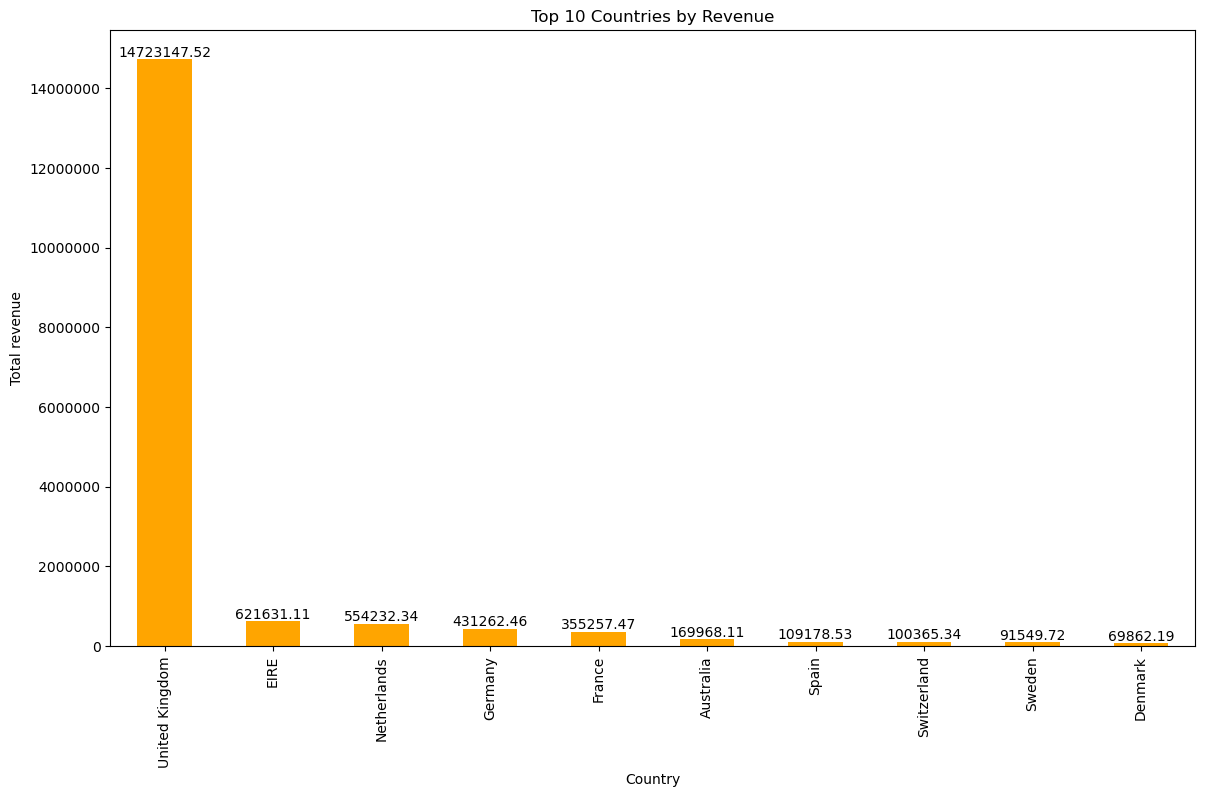

In [12]:
top10_country_revenue.plot(kind='bar',title='Top 10 Countries by Revenue', figsize=(14,8),color='orange')
plt.xlabel('Country')
plt.ylabel('Total revenue')
plt.ticklabel_format(style='plain', axis='y')
for i, v in enumerate(top10_country_revenue.values):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.show()

## Phase 4: RFM Feature Engineering
**Objective:** Transform our transactional dataset into a customer-centric behavioral dataset. We will calculate three metrics for every unique `Customer ID`:
* **Recency (R):** How many days ago did they make their last purchase?
* **Frequency (F):** How many separate orders (Invoices) have they made?
* **Monetary (M):** How much total money have they spent with us?

In [8]:
snapshot_date = df_filtered['InvoiceDate'].max() + pd.Timedelta(days=1)  

* Obtained snapshot_date to get Recency, In historical datasets, we pretend "today" is one day after the very last transaction in the dataset.

In [9]:
recency= lambda x :(snapshot_date - x.max()).days

In [10]:
df_rfm=df_filtered.groupby(['Customer ID']).agg(Recency=('InvoiceDate',recency),
                                         Frequency=('Invoice','nunique'),
                                         Monetary=('TotalPrice','sum')).reset_index()

In [11]:
df_rfm

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40
...,...,...,...,...
5876,18283.0,4,22,2736.65
5877,18284.0,432,1,461.68
5878,18285.0,661,1,427.00
5879,18286.0,477,2,1296.43


## Phase 5: Machine Learning

### Step 6: Data Pre-Processing & Scaling
*Technical Insight:* Clustering is highly sensitive to the scale of the data because it utilizes Euclidean distance. 
Since our `Monetary` feature is vastly larger in magnitude than `Frequency`, we must apply standard scaling to ensure the algorithm treats all three behavioral axes with equal weight.

In [12]:
scaler=StandardScaler()

* We Exclude the `Customer ID` from the model, as it is a categorical identifier, not a behavioral trait.

In [13]:
behavioural_df=df_rfm.drop('Customer ID', axis=1)
behavioural_df.head(5)

,Recency,Frequency,Monetary
0,326,12,77556.46
1,2,8,5633.32
2,75,5,2019.40
3,19,4,4428.69
4,310,1,334.40


In [14]:
scaled_data=scaler.fit_transform(behavioural_df)

In [15]:
rfm_scaled=pd.DataFrame(scaled_data, columns=behavioural_df.columns, index=behavioural_df.index )
rfm_scaled

,Recency,Frequency,Monetary
0,0.594598,0.439049,5.059391
1,-0.952264,0.131635,0.177579
2,-0.603743,-0.098925,-0.067718
3,-0.871102,-0.175779,0.095814
4,0.518209,-0.406339,-0.182088
...,...,...,...
5876,-0.942716,1.207584,-0.019034
5877,1.100670,-0.406339,-0.173449
5878,2.193977,-0.406339,-0.175803
5879,1.315512,-0.329486,-0.116790


### Step 7: Determining the Optimal Clusters (The Elbow Method)
* Technical Insight:* K-Means requires the user to pre-define the number of clusters ($K$). To find the optimal $K$ without guessing, we run the algorithm multiple times (from 1 to 10 clusters) and calculate the **Inertia** (Within-Cluster Sum of Squares) for each run. 
* Inertia measures how tightly packed the clusters are. We plot these values to find the "elbow" of the curve—the point where adding more clusters no longer provides a significant drop in inertia.

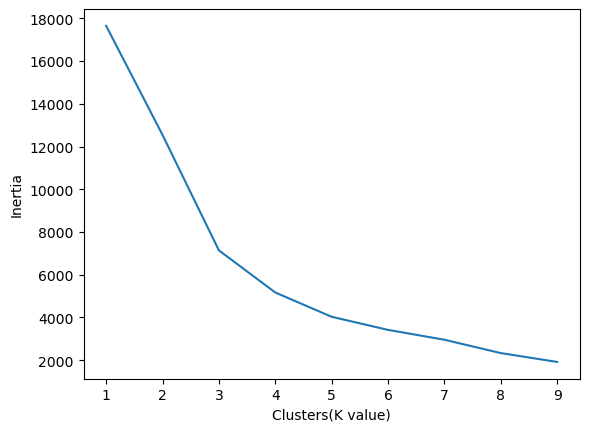

In [17]:
inertia=[]
for i in range(1,10):
    kmeans=KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
plt.plot(list(range(1,10)), inertia)
plt.xlabel('Clusters(K value)')
plt.ylabel('Inertia')
plt.show()

### Business Insight: Selecting the Optimal Clusters
**Decision: We will proceed with $K=4$ clusters.**

* **Mathematical Justification:** The Elbow Plot demonstrates a sharp decline in inertia from $K=1$ to $K=3$. After $K=4$, the curve begins to flatten significantly, indicating diminishing returns. Adding more clusters beyond this point artificially fragments the data without meaningfully increasing the compactness of the groups.
* **Business Justification:** A segmentation model is only valuable if it is actionable. While $K=6$ or $K=8$ might offer slight mathematical improvements, a marketing team cannot effectively manage 8 distinct automated campaigns. Four segments provide the perfect strategic balance, allowing us to categorize users into highly actionable tiers (e.g., VIPs, Loyal Customers, Promising/New, and At-Risk).

In [16]:
kmeans=KMeans(n_clusters=4,random_state=42)

In [17]:
cluster=kmeans.fit_predict(rfm_scaled)

In [18]:
df_rfm['Cluster']=cluster

In [19]:
df_rfm.head(5)

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,12,77556.46,0
1,12347.0,2,8,5633.32,0
2,12348.0,75,5,2019.40,0
3,12349.0,19,4,4428.69,0
4,12350.0,310,1,334.40,1


## Phase 6: Cluster Profiling & Business Translation

### Step 8: Building the Personas
*Business Insight:* The machine learning algorithm has mathematically grouped our customers, but we must translate these numerical clusters into actionable marketing personas. By calculating the average Recency, Frequency, and Monetary values for each cluster, alongside the total volume of customers in each tier, we can identify our VIPs, our Loyalists, and our At-Risk demographics.

In [22]:
df_rfm.groupby('Cluster').agg(Avg_recency=('Recency', 'mean'),
                             Avg_Frequency=('Frequency','mean'),
                             Avg_Monetory=('Monetary','mean'),
                             Count=('Customer ID','count'),
                             Total=('Monetary','sum')).round(2).reset_index()

,Cluster,Avg_recency,Avg_Frequency,Avg_Monetory,Count,Total
0,0,66.89,7.31,3009.12,3840,11555035.56
1,1,463.03,2.21,765.75,2002,1533037.65
2,2,25.94,103.74,83086.08,35,2908012.79
3,3,3.50,212.75,436835.79,4,1747343.17


In [23]:
# 1. Map your clean, professional persona names
persona_mapping = {
    0: 'Loyal',
    1: 'At Risk',
    2: 'VIP',
    3: 'Wholesale'
}

df_rfm['Persona'] = df_rfm['Cluster'].map(persona_mapping)

# 2. Export the final engine to a CSV file
df_rfm.to_csv('Customer_Segmentation_Final.csv', index=False)

# 3. View the final product
df_rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster,Persona
0,12346.0,326,12,77556.46,0,Loyal
1,12347.0,2,8,5633.32,0,Loyal
2,12348.0,75,5,2019.40,0,Loyal
3,12349.0,19,4,4428.69,0,Loyal
4,12350.0,310,1,334.40,1,At Risk


* **Loyal (Cluster 0):** The core revenue engine. Consistent buyers with healthy average order values. *(Action: Nurture with standard product updates).*
* **At Risk (Cluster 1):** Customers dormant for 400+ days. *(Action: Trigger automated, high-value win-back discount codes).*
* **VIP (Cluster 2):** High-frequency, high-spend retail users. *(Action: Reward with early access and exclusive loyalty perks).*
* **Wholesale (Cluster 3):** Discovered a hidden B2B segment of massive statistical outliers spending £400k+. *(Action: Assign dedicated human Account Managers to negotiate bulk contracts).*

## Phase 7: Production Pipeline Architecture (Real-Time Inference)

### The Business Challenge: The "Cold Start" & Live Prediction
A machine learning model is only valuable if it can evaluate new data in real-time. When a new customer makes a purchase, the frontend application will not send pre-calculated RFM metrics; it will send a raw JSON payload of their transaction history. 

### The Hybrid Scikit-Learn Pipeline
Standard Scikit-Learn transformers cannot handle complex Pandas date math or row-level aggregations. To bridge this gap, we are building a hybrid custom pipeline:
1. **The Custom ETL Transformer:** We engineer a Python function that ingests raw transactional dictionaries and calculates Recency, Frequency, and Monetary metrics on the fly. We wrap this function in Scikit-Learn's `FunctionTransformer`.
2. **The Unified Pipeline:** We chain our custom ETL transformer, the `StandardScaler`, and the `KMeans` model together using `sklearn.pipeline.Pipeline`. 
3. **Serialization:** This allows us to export the entire end-to-end inference engine as a single `.pkl` file, ready for seamless deployment to a FastAPI backend.

In [30]:
def extract_rfm(rawdata):
    user_df=pd.DataFrame(rawdata)

    #Filtering the on Quantity>0 Data as -Quantity is of Returned to avoid miss calculation of Monetary
    filter_df=user_df[user_df['Quantity']>0].copy()

    #Getting current date and Obtaining the last date of purchase of a customer and obtaining Recency
    current_date=pd.Timestamp.now()
    filter_df['InvoiceDate']=pd.to_datetime(filter_df['InvoiceDate'])
    recency=lambda x : (current_date- x.max()).days

    #Obtaining Total Revenue generated by each customer  
    filter_df['TotalPrice']=filter_df['Quantity']*filter_df['Price']

    #Calculating RFM 
    df_rfm=filter_df.groupby('Customer ID').agg( Recency=('InvoiceDate',recency),
                                              Frequency=('Invoice','nunique'),
                                              Monetary=('TotalPrice','sum') ).reset_index()
    rfm=df_rfm[['Recency','Frequency','Monetary']]
    return rfm

* Custom ETL Transformer
* we will import the above function as module to perform ETL on production 

In [20]:
from ETL_transformer import extract_rfm
help(extract_rfm)

Help on function extract_rfm in module ETL_transformer:

extract_rfm(rawdata)
    The Custom ETL Transformer: We engineer a Python function that ingests raw transactional dictionaries and calculates Recency, Frequency, and Monetary metrics on the fly.



In [21]:
etl_transformer=FunctionTransformer(extract_rfm)

* Pipeline

In [22]:
pipeline=Pipeline([('rfm',etl_transformer),
                   ('scaler',scaler),
                   ('model',kmeans)])

In [23]:
batch_customer_payload = [
    {'Customer ID': 99999, 'InvoiceDate': '2026-03-15', 'Invoice': 'A001', 'Quantity': 10, 'Price': 500.00},
    {'Customer ID': 99999, 'InvoiceDate': '2026-04-01', 'Invoice': 'A002', 'Quantity': 5, 'Price': 200.00},
    {'Customer ID': 88888, 'InvoiceDate': '2024-10-15', 'Invoice': 'B001', 'Quantity': 2, 'Price': 25.00},
    {'Customer ID': 88888, 'InvoiceDate': '2024-10-16', 'Invoice': 'B002', 'Quantity': -1, 'Price': 25.00} 
]

In [36]:
predictions=pipeline.predict(dat)
print(predictions)

[1 0 1 0]


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [32]:
dat= {'Customer ID': [99999,99999,88888,88888,12354,12354,1345],
     'InvoiceDate': ['2026-03-15','2026-04-01','2024-10-15','2024-10-15','2024-10-25','2025-10-10','2025-05-15'],
     'Invoice': ['A001','A002','B001','B002','c001','c002','b0089'],
     'Quantity':[10,5,2,-1,0,5,10 ],
     'Price': [500.00,200.00,25.00,25.00,50.00,100.00,45.75],
     }

In [33]:
temp_df=extract_rfm(dat)
temp_df

,Recency,Frequency,Monetary
0,327,1,457.5
1,179,1,500.0
2,539,1,50.0
3,6,2,6000.0


### Saving model pipeline

In [37]:
import joblib 
joblib.dump(pipeline,'customer_segmentation.pkl')
print('model saved')  

model saved
